# Ammonia Synthesis Kinetics

Test of kinetics from Rossetti et al ideal plug flow reactor and comparison to their experimenal data.
Also implementation of ideally mixed contiuous reactor at specified pressure.

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import R  # Ideal gas constant in J/(mol·K)
import pandas as pd
import re

# Load the CSV file into a DataFrame
df = pd.read_csv("ammonia_synthesis_data_rossetti_et_al.csv")

# Function to extract columns and molar flow per volume reactor
def extract_columns_and_molar_flow(df):
    """
    Extract columns starting with 'GHSV_' and calculate molar flow per volume reactor in SI units.

    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing the columns with GHSV values.

    Returns:
    --------
    list of tuples
        List of (column_name, molar_flow_per_volume) pairs in SI units.
    """
    # Define standard temperature and pressure
    standard_temperature = 273.15  # Kelvin (0°C)
    standard_pressure = 101325  # Pascals (1 atm)

    columns_and_molar_flow = []
    for col in df.columns:
        match = re.match(r"GHSV_(\d+)", col)
        if match:
            gHSV = float(match.group(1))  # GHSV in 1/h
            # Convert GHSV to molar flow per volume reactor in SI units (mol/m³/s)
            molar_flow_per_volume = gHSV / 3600 * (standard_pressure / (R * standard_temperature))
            columns_and_molar_flow.append((col, molar_flow_per_volume))
    return columns_and_molar_flow

# Extract columns and molar flow per volume reactor
columns_and_molar_flow = extract_columns_and_molar_flow(df)

# Display the first few rows
print(df.head())


   Test  Pressure (bar)  Temperature (°C)  H2/N2 Ratio  GHSV_50000  \
0     1             100               430          1.5       13.20   
1     2             100               370          1.5        3.55   
2     3              85               370          1.5        3.41   
3     4              85               430          1.5       11.82   
4     7              70               370          3.0        2.19   

   GHSV_60000  GHSV_90000  GHSV_120000  GHSV_200000  GHSV_300000 GHSV_400000  \
0       12.62       11.66        10.05         7.62         4.87        3.60   
1        3.32        2.62         2.24         1.48         0.89        0.60   
2        3.08        2.43         2.00         1.43          NaN               
3       11.33        9.53         8.25         5.46         4.17        3.30   
4        1.91        1.43         1.14         0.60          NaN               

   TAve (°C)  Exp/Equ  
0      431.1     0.80  
1      366.9     0.17  
2      366.9     0.16  
3 

In [93]:
from ammonia_synthesis_kinetics import AmmoniaSynthesisKinetics
from scipy.integrate import solve_ivp
from pymrm import NumJac
from scipy.constants import R  # Ideal gas constant in J/(mol·K)
from scipy.sparse import eye_array, csc_array
from scipy.sparse.linalg import spsolve

#rho_c = 590.0
#Dcat = 1.0 / 3.0
#eps = 0.4
#rho_b = rho_c * Dcat * (1 - eps)

species = ['N2', 'H2', 'NH3']
kinetics = AmmoniaSynthesisKinetics(species, rho_b=1.0, rho_c=1.0)

def ode_plugflow(F, p, kinetics):
    mol_frac = F / np.sum(F)  # Convert flow rates to mole fractions
    p_partial = mol_frac * p  # Convert mole fractions to partial pressures
    return kinetics(p_partial)  # Convert back to mol/m³/s

class CSTR:
    def __init__(self, kinetics, p=None, T=None):
        kinetics.set_T_and_p(T, p)
        self.p = kinetics.p
        self.T = kinetics.T
        self.numjac = NumJac(shape=kinetics.stoichiometry.shape)

    def __call__(self, F_in):
        jac_cnst = -eye_array(F_in.size,format='csc')
        F = F_in.copy()
        for i in range(50):
            Ftot = np.sum(F)
            p_div_F_tot = self.p / Ftot
            p_partial = p_div_F_tot * F
            g_react, jac_react = self.numjac(lambda F: kinetics(p_div_F_tot * F), F)
            #g_react = kinetics(p_div_F_tot * F)
            #v = (jac_react @ F)/ Ftot**2
            #v_sparse = csc_array(v[:, None])  # n×1
            #F_sparse = csc_array(F[None, :])
            #jac_react = jac_react - v_sparse @ F_sparse
            
            g_value = F_in - F + g_react
            jac = jac_cnst + jac_react
            F -= spsolve(jac, g_value)
            if np.linalg.norm(g_value) < 1e-4*np.abs(F_in.max()):
                break
        return F
    

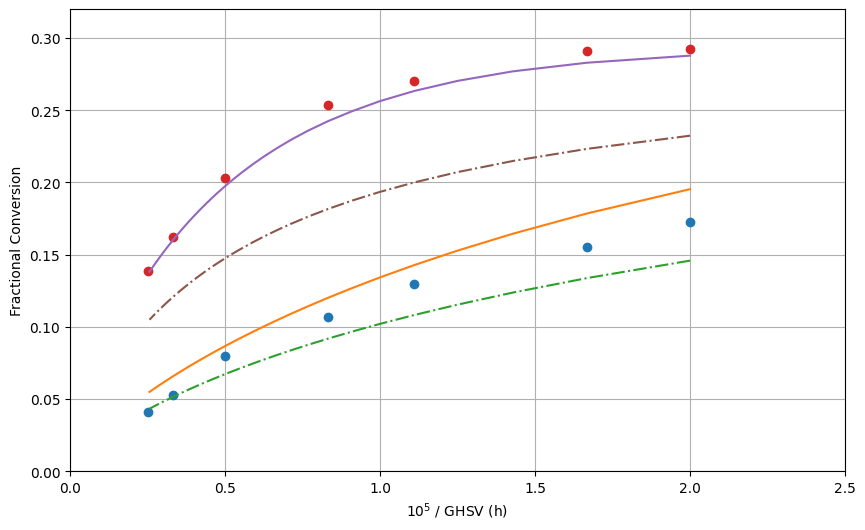

In [94]:
plt.figure(figsize=(10, 6))
standard_temperature = 273.15  # Kelvin (0°C)
standard_pressure = 101325  # Pascals (1 atm)
tests = [11, 22]
for test in tests:
    row = df[df["Test"] == test].iloc[0]
    gHSV = []
    conversion = []

    q = float(row['H2/N2 Ratio'])  # Ratio of H2 to N2
    for col, _ in columns_and_molar_flow:
        match = re.match(r"GHSV_(\d+)", col)
        if match:
            gHSV.append(float(match.group(1)))
            frac_NH3 = 1e-2*float(row[col])  # Fraction of NH3
            eta = 3.0 * (1.0 + 1.0 / q) * frac_NH3 / (2.0 * (1 + frac_NH3))  # Conversion of H2
            conversion.append(eta)
    # Plot the conversion against GHSV
    plt.plot(1e5 / np.array(gHSV), conversion, 'o')

    p = 1e5*row['Pressure (bar)']
    kinetics.set_T_and_p(273.15+row['Temperature (°C)'], p)  # Set temperature and pressure for kinetics
    conversion_pfr = []
    conversion_cstr = []
    cstr = CSTR(kinetics)  # Create a CSTR instance
    gHSV = np.arange(50000, 400000, 10000)  # GHSV values for interpolation
    composition = np.array([1.0 / (1.0 + q), q / (1.0 + q), 0.0])  # N2, H2, NH3 composition
    for gHSV_value in gHSV:
        F0 = gHSV_value/3600 * (standard_pressure/(R*standard_temperature))*composition  # Initial flow rates
        sol = solve_ivp(lambda zeta, F: ode_plugflow(F, p, kinetics), [0, 1], F0, t_eval=[1])
        conversion_pfr.append((F0[1] - sol.y[1, 0])/F0[1])
        F = cstr(F0)
        conversion_cstr.append((F0[1] - F[1])/F0[1])
    plt.plot(1e5 / np.array(gHSV), conversion_pfr, '-')
    plt.plot(1e5 / np.array(gHSV), conversion_cstr, '-.')
    
plt.xlabel(r"$10^5$ / GHSV (h)")
plt.ylabel("Fractional Conversion")
plt.xlim(0, 2.5)
plt.ylim(0, 0.32)
plt.grid()
plt.show()


In [86]:

F0 = np.array([1.0e3, 3.0e3, 0.0])  # Initial molar flow rates for N2, H2, NH3
cstr = CSTR(kinetics, p=1e7, T=600)  # Create a CSTR instance with pressure and temperature
F = cstr(F0)
print(F)
print(np.sum(np.array([2.0,0.0,1.0])*(F-F0)))
print(np.sum(np.array([0.0,2.0,3.0])*(F-F0)))
print((F0[1]-F[1])/F0[1])

[9.99857658e+02 2.99957298e+03 2.84683048e-01]
1.0219602941674566e-13
1.8879942054184085e-10
0.00014234152404772734
